# 🏏 IPL Auction 2024 — Exploratory Data Analysis

**Dataset:** `iplauction2023.csv`  
**Goal:** Understand the structure of IPL auction data and uncover patterns around player pricing, nationality, playing style, and franchise spending behavior.

---

## 📋 Table of Contents
1. [Import Libraries](#1)
2. [Load & Preview Data](#2)
3. [Data Cleaning & Missing Values](#3)
4. [Univariate Analysis — Numerical Features](#4)
5. [Univariate Analysis — Categorical Features](#5)
6. [Bivariate Analysis — Sold & Retained Players](#6)
7. [Franchise-Level Analysis](#7)
8. [Nationality-Level Analysis](#8)
9. [Key Findings](#9)

---
## 1. Import Libraries <a id='1'></a>

In [1]:

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
import scipy.stats

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

---
## 2. Load & Preview Data <a id='2'></a>

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/Shontu72/python_data-science-learning__-/main/DATA/iplauction2023.csv')
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
df.head()

Shape: 309 rows × 7 columns


,name,player style,nationality,base price (in lacs),final price (in lacs),franchise,status
0,Harshit Rana,Bowler,India,NaN,20.0,KKR,RETAINED
1,Ekant Sen,Batter,India,20.0,NaN,NaN,UNSOLD
2,Wayne Parnell,Allrounder,South Africa,75.0,NaN,NaN,UNSOLD
3,Shakib Al Hasan,Allrounder,Bangladesh,150.0,150.0,KKR,SOLD
4,Joe Root,Batter,England,100.0,100.0,RR,SOLD


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309 entries, 0 to 308
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   name                   309 non-null    object 
 1   player style           309 non-null    object 
 2   nationality            309 non-null    object 
 3   base price (in lacs)   151 non-null    float64
 4   final price (in lacs)  238 non-null    float64
 5   franchise              238 non-null    object 
 6   status                 309 non-null    object 
dtypes: float64(2), object(5)
memory usage: 17.0+ KB


---
## 3. Data Cleaning & Missing Values <a id='3'></a>

Three columns have missing values. Before filling them, we investigate **why** they are missing — missing data is often meaningful in auction datasets.

In [6]:
# Check missing value counts per column
df.isnull().sum()

,0
name,0
player style,0
nationality,0
base price (in lacs),158
final price (in lacs),71
franchise,71
status,0


In [7]:
# Investigate: what is the status of players with no base price?
# Hypothesis: retained players may not have a listed base price
df[df['base price (in lacs)'].isna()]['status'].value_counts()

,count
status,
RETAINED,158


In [8]:
# Investigate: what is the status of players with no final price?
# Hypothesis: unsold players have no final price
df[df['final price (in lacs)'].isna()]['status'].value_counts()

,count
status,
UNSOLD,71


In [9]:
# Confirm: do unsold players belong to any franchise?
df[df['status'] == 'UNSOLD']['franchise'].isna().value_counts()
# Expected: all True — unsold players have no franchise

,count
franchise,
True,71


**Summary of missing value logic:**

| Column | Missing because |
|---|---|
| `base price (in lacs)` | Player was **RETAINED** — no base price needed |
| `final price (in lacs)` | Player was **UNSOLD** — no final price exists |
| `franchise` | Player was **UNSOLD** — no team acquired them |

Missing values are **not random** — the basic game rules are attained here. We fill with 0 / placeholder accordingly.

In [10]:
# Fill missing values with meaningful defaults
df['base price (in lacs)'].fillna(0, inplace=True)
df['final price (in lacs)'].fillna(0, inplace=True)
df['franchise'].fillna('No Team', inplace=True)

# Confirm no remaining nulls
print("Remaining nulls:")
print(df.isnull().sum())

Remaining nulls:
name                     0
player style             0
nationality              0
base price (in lacs)     0
final price (in lacs)    0
franchise                0
status                   0
dtype: int64


/tmp/ipykernel_2103/4039902845.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['base price (in lacs)'].fillna(0, inplace=True)
/tmp/ipykernel_2103/4039902845.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', tr

In [11]:
# Overview of player status distribution
status_pct = df['status'].value_counts(normalize=True) * 100
print("Player status breakdown (%):\n")
print(status_pct.round(2))

Player status breakdown (%):

status
RETAINED    51.13
SOLD        25.89
UNSOLD      22.98
Name: proportion, dtype: float64


---
## 4. Univariate Analysis — Numerical Features <a id='4'></a>

We analyze the distribution of `base price` and `final price` using histograms, boxplots, and distribution plots with summary statistics.

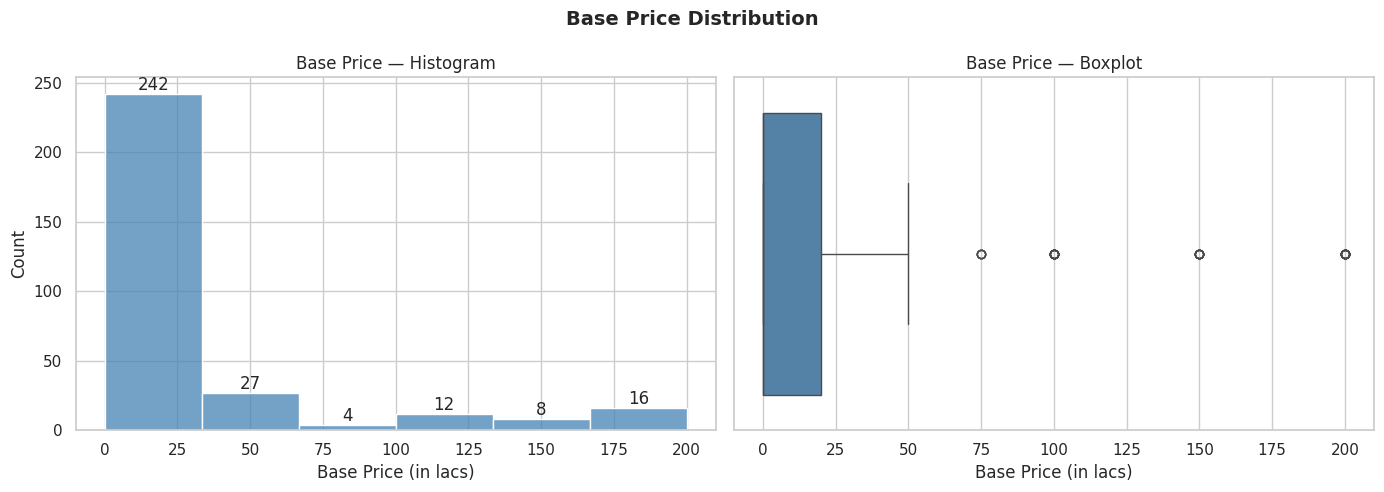

In [12]:
# Base Price Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = sns.histplot(data=df, x='base price (in lacs)', bins=6, ax=axes[0], color='steelblue')
for container in ax.containers:
    ax.bar_label(container)
axes[0].set_title('Base Price — Histogram')
axes[0].set_xlabel('Base Price (in lacs)')

# Boxplot
sns.boxplot(data=df, x='base price (in lacs)', ax=axes[1], color='steelblue')
axes[1].set_title('Base Price — Boxplot')
axes[1].set_xlabel('Base Price (in lacs)')

plt.suptitle('Base Price Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Base price — interactive summary table
i = df['base price (in lacs)'].describe().index
v = round(df['base price (in lacs)'].describe(), 3).values
fig = go.Figure(data=[go.Table(
    header=dict(values=list(i), fill_color='steelblue', font=dict(color='white')),
    cells=dict(values=v)
)])
fig.update_layout(title='Base Price — Summary Statistics', width=600, height=250)
fig.show()

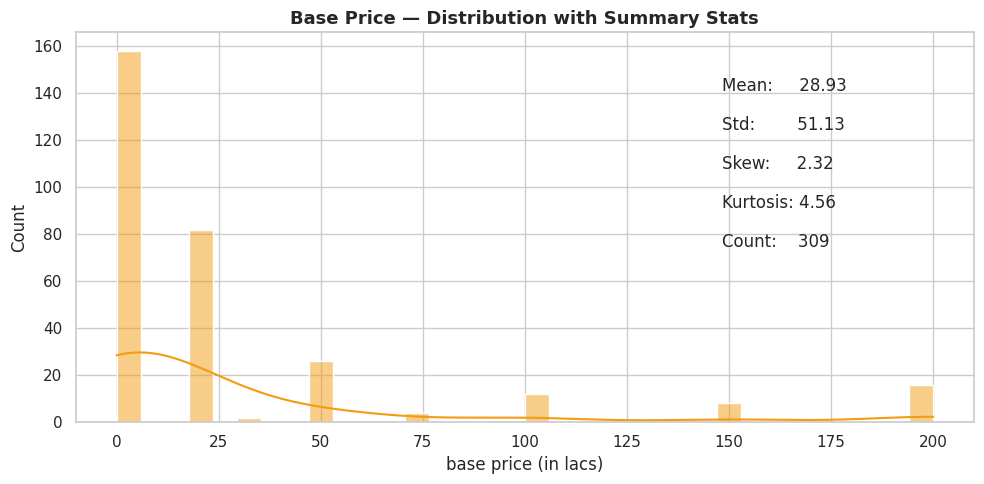

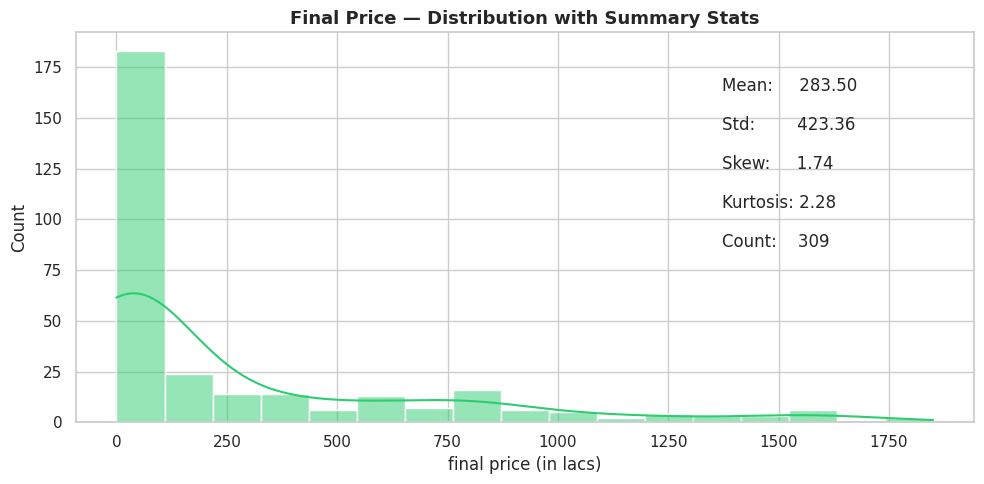

In [15]:
def plot_distribution(series, color, title):
    """Plot a KDE distribution with summary stats annotated on the chart."""
    stats = series.describe()
    skewness = scipy.stats.skew(series)
    kurtosis = scipy.stats.kurtosis(series)

    plt.figure(figsize=(10, 5))
    sns.histplot(series, kde=True, color=color)
    plt.text(0.72, 0.85, f"Mean:     {stats['mean']:.2f}", transform=plt.gca().transAxes)
    plt.text(0.72, 0.75, f"Std:        {stats['std']:.2f}", transform=plt.gca().transAxes)
    plt.text(0.72, 0.65, f"Skew:     {skewness:.2f}", transform=plt.gca().transAxes)
    plt.text(0.72, 0.55, f"Kurtosis: {kurtosis:.2f}", transform=plt.gca().transAxes)
    plt.text(0.72, 0.45, f"Count:    {stats['count']:.0f}", transform=plt.gca().transAxes)
    plt.title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_distribution(df['base price (in lacs)'], '#F39C12', 'Base Price — Distribution with Summary Stats')
plot_distribution(df['final price (in lacs)'], '#2ECC71', 'Final Price — Distribution with Summary Stats')

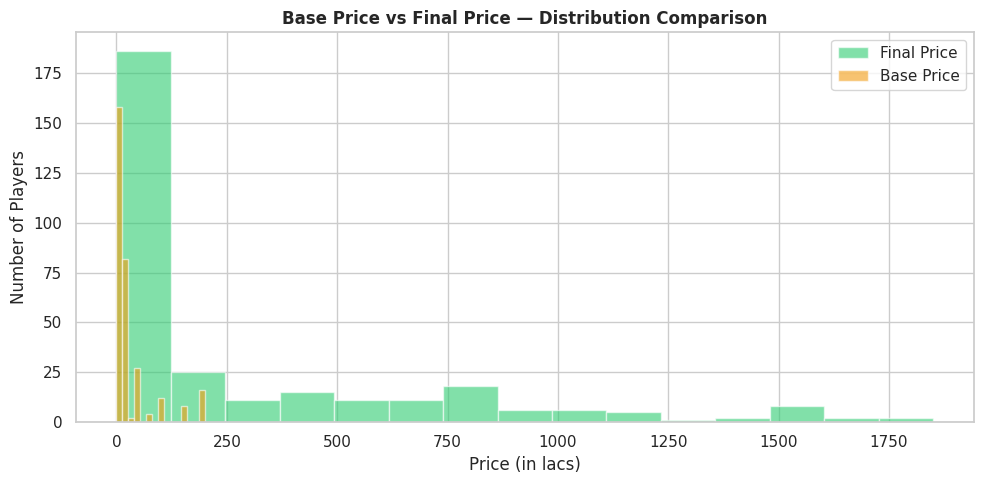

In [16]:
# Both prices overlaid — shows final price has a wider range
plt.figure(figsize=(10, 5))
df['final price (in lacs)'].plot(kind='hist', alpha=0.6, label='Final Price', color='#2ECC71', bins=15)
df['base price (in lacs)'].plot(kind='hist', alpha=0.6, label='Base Price', color='#F39C12', bins=15)
plt.xlabel('Price (in lacs)')
plt.ylabel('Number of Players')
plt.title('Base Price vs Final Price — Distribution Comparison', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

> 📌 **Observation:** As High frequency of 0 in 'base price' and 'final price' due to retained and unsold players, respectively, and Final price has a much wider spread than base price, indicating that bidding wars pushed several players well above their base values. As a result, distributions are **right-skewed** — most players sold at lower prices with a few high-value outliers.

---
## 5. Univariate Analysis — Categorical Features <a id='5'></a>

We look at the distribution of player style, nationality, and franchise.

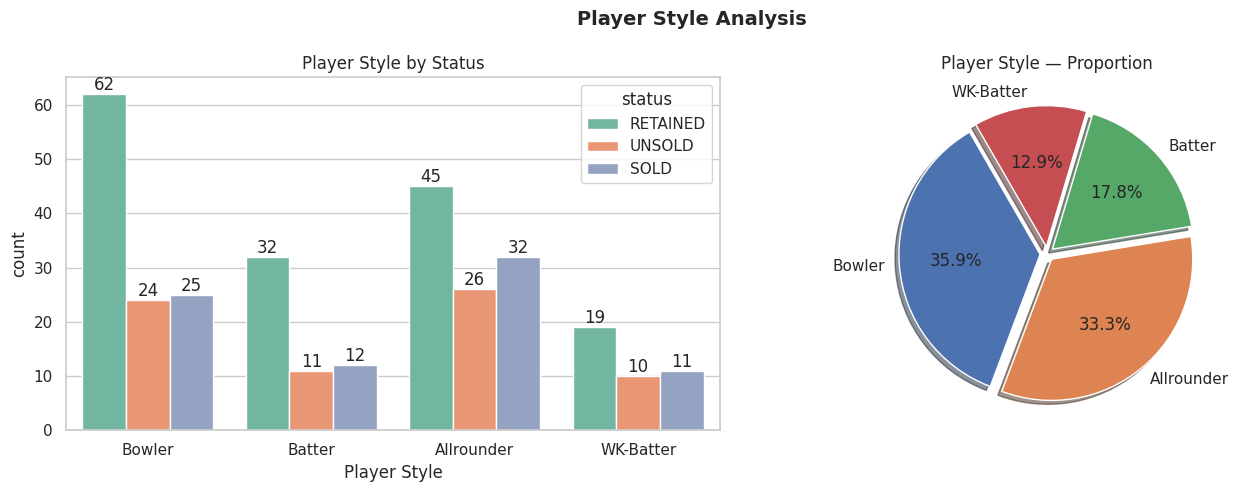

In [17]:
# Player Style
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
ax = sns.countplot(data=df, x='player style', hue='status', ax=axes[0], palette='Set2')
for container in ax.containers:
    ax.bar_label(container)
axes[0].set_title('Player Style by Status')
axes[0].set_xlabel('Player Style')

# Pie chart
counts = df['player style'].value_counts()
axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%', explode=[0.05]*len(counts),
            shadow=True, startangle=120)
axes[1].set_title('Player Style — Proportion')

plt.suptitle('Player Style Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [18]:
# Retention rate by player style
for style in df['player style'].dropna().unique():
    total = df[df['player style'] == style]['status'].count()
    retained = df[(df['player style'] == style) & (df['status'] == 'RETAINED')]['status'].count()
    pct = (retained / total) * 100
    print(f"{style:<15} → Retention rate: {pct:.1f}%  ({retained}/{total})")

Bowler          → Retention rate: 55.9%  (62/111)
Batter          → Retention rate: 58.2%  (32/55)
Allrounder      → Retention rate: 43.7%  (45/103)
WK-Batter       → Retention rate: 47.5%  (19/40)


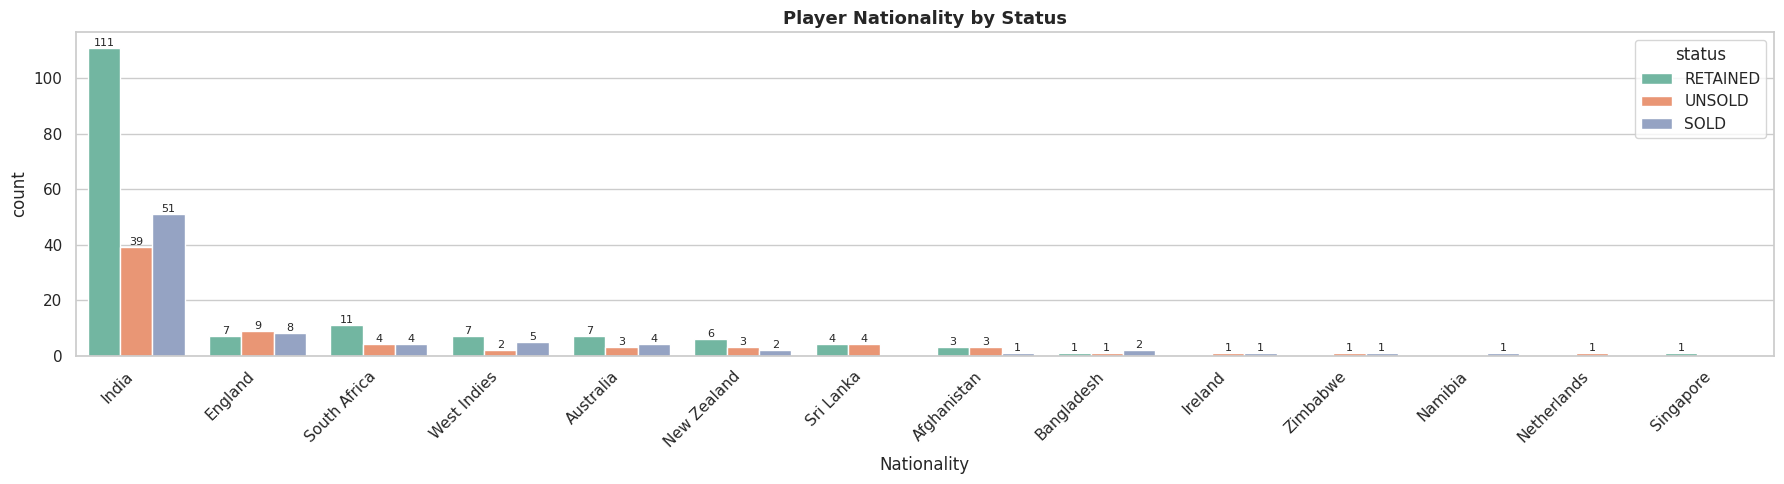

In [19]:
#Nationality
plt.figure(figsize=(18, 5))
ax = sns.countplot(data=df, x='nationality', hue='status', palette='Set2',
                   order=df['nationality'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.title('Player Nationality by Status', fontsize=13, fontweight='bold')
plt.xlabel('Nationality')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Observation:** Although the proportion of bowlers is relatively high, all-rounders are in greater demand than specialist batsmen and bowlers. This suggests that shorter formats of cricket place a higher value on versatile players who can contribute in multiple roles.

Among overseas players, English, South African, West Indian, and Australian cricketers are the most sought-after.

---
## 6. Bivariate Analysis — Sold & Retained Players <a id='6'></a>

We filter to only **SOLD** and **RETAINED** players (excluding unsold) for price-related analysis.

In [20]:
# Create filtered subsets
df_filtered = df[df['status'].isin(['RETAINED', 'SOLD'])].copy()
df_retained = df[df['status'] == 'RETAINED'].reset_index(drop=True)
df_sold     = df[df['status'] == 'SOLD'].reset_index(drop=True)

print(f"Sold: {len(df_sold)} | Retained: {len(df_retained)} | Total (excl. unsold): {len(df_filtered)}")

Sold: 80 | Retained: 158 | Total (excl. unsold): 238


In [21]:
# Final price distribution by player style
plyr_stats = df_filtered.groupby('player style')['final price (in lacs)'].describe()
print("Final price stats by player style:\n")
plyr_stats

Final price stats by player style:



,count,mean,std,min,25%,50%,75%,max
player style,,,,,,,,
Allrounder,77.0,376.298701,485.561532,20.0,20.00,100.0,650.00,1850.0
Batter,44.0,425.113636,441.586053,20.0,50.00,260.0,781.25,1600.0
Bowler,87.0,290.344828,350.931313,20.0,30.00,120.0,420.00,1500.0
WK-Batter,30.0,488.666667,581.006756,20.0,31.25,170.0,675.00,1700.0


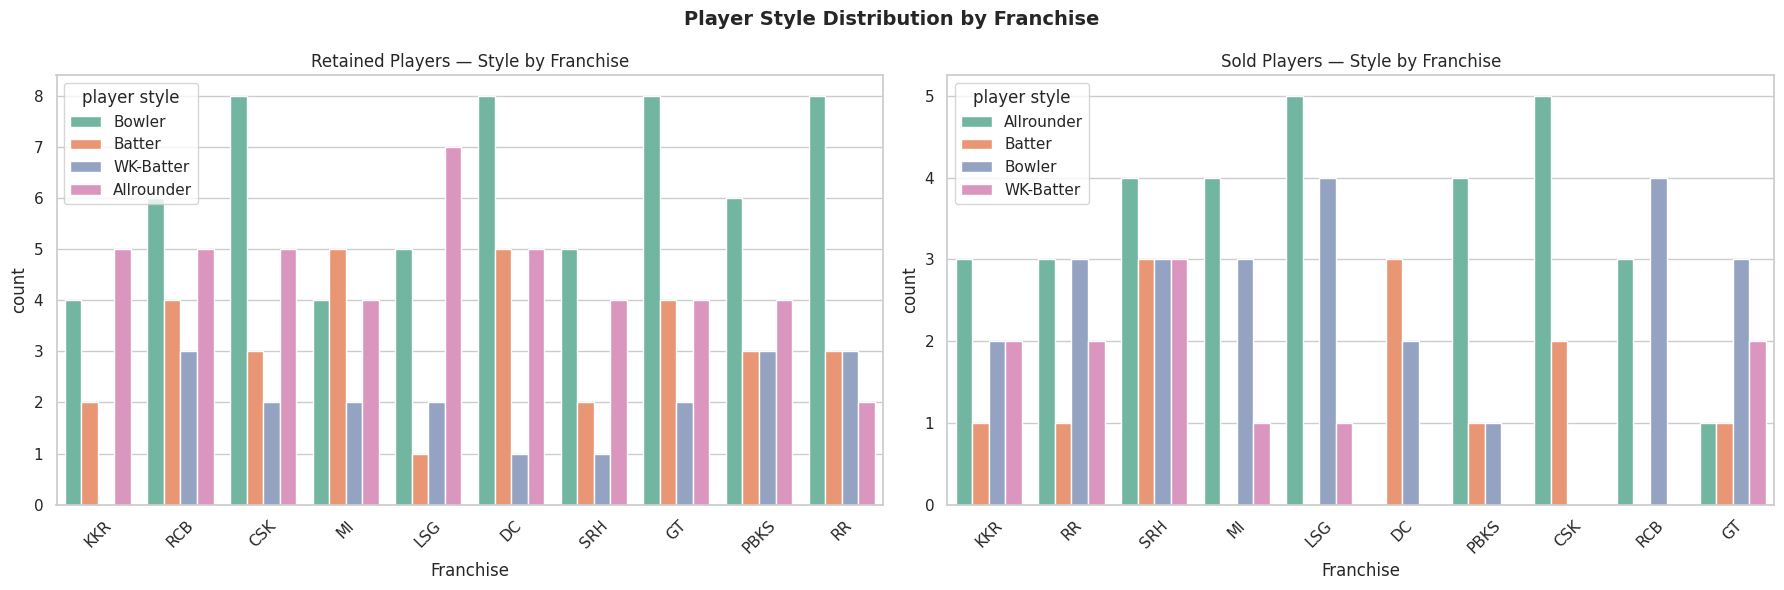

In [22]:
# Player style distribution across franchises (retained vs sold)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.countplot(data=df_retained, x='franchise', hue='player style', palette='Set2', ax=axes[0])
axes[0].set_title('Retained Players — Style by Franchise')
axes[0].set_xlabel('Franchise')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=df_sold, x='franchise', hue='player style', palette='Set2', ax=axes[1])
axes[1].set_title('Sold Players — Style by Franchise')
axes[1].set_xlabel('Franchise')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Player Style Distribution by Franchise', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

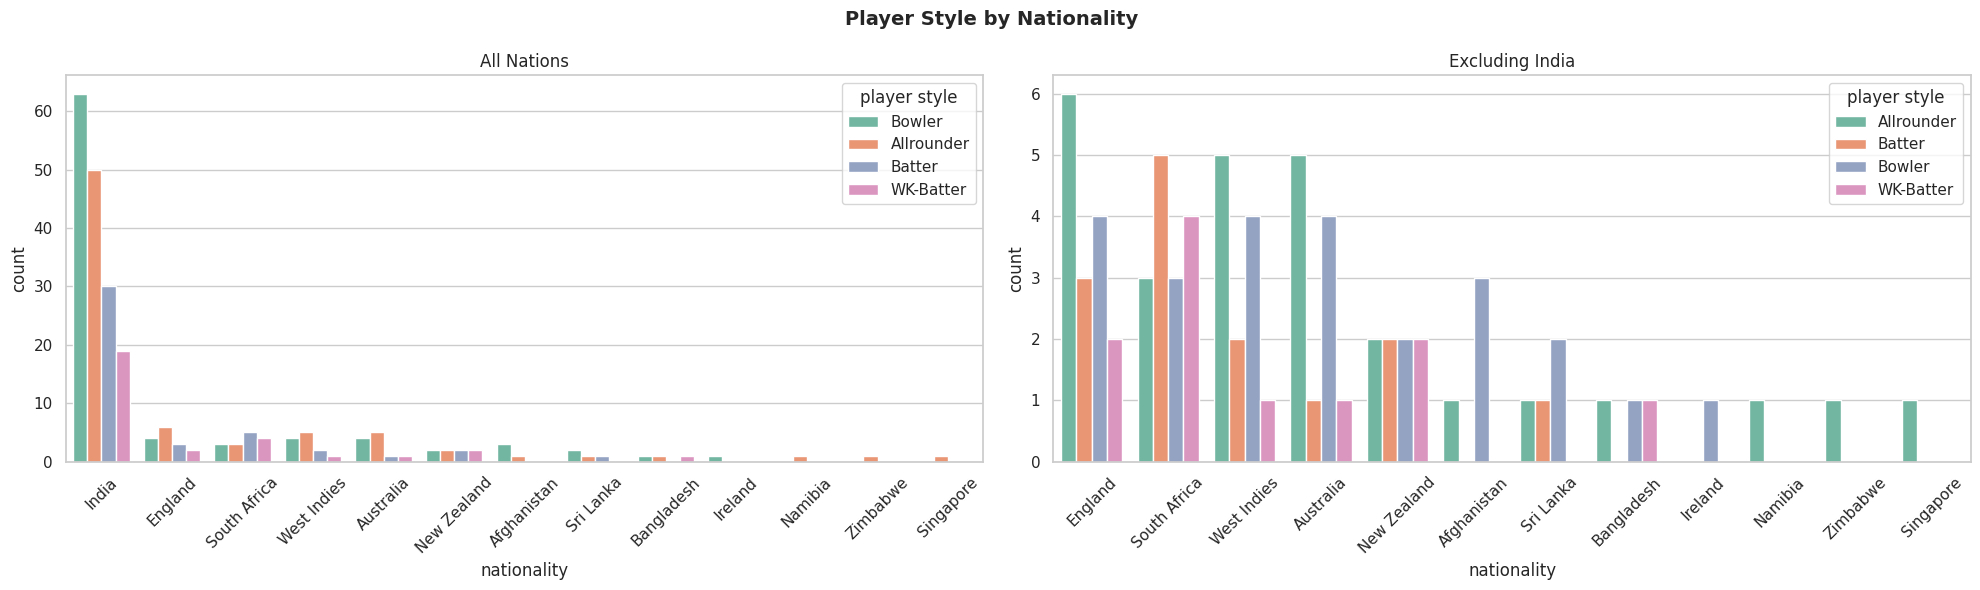

In [23]:
# Player style across nationalities — with and without India (dominant country)
fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.countplot(x='nationality', hue='player style', data=df_filtered,
              order=df_filtered['nationality'].value_counts().index, palette='Set2', ax=axes[0])
axes[0].set_title('All Nations')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='nationality', hue='player style',
              data=df_filtered[df_filtered['nationality'] != 'India'],
              order=df_filtered[df_filtered['nationality'] != 'India']['nationality'].value_counts().index,
              palette='Set2', ax=axes[1])
axes[1].set_title('Excluding India')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Player Style by Nationality', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 7. Franchise-Level Analysis <a id='7'></a>

How did each franchise spend? Which franchises invested more per player on average?

In [24]:
# Total and average spend per franchise
franchise_spend = df_filtered.groupby('franchise')['final price (in lacs)'].agg(['sum', 'mean', 'count'])
franchise_spend.columns = ['Total Spend (lacs)', 'Avg per Player (lacs)', 'Players Bought']
franchise_spend.sort_values('Total Spend (lacs)', ascending=False)

,Total Spend (lacs),Avg per Player (lacs),Players Bought
franchise,,,
MI,9420.0,409.565217,23
CSK,9350.0,374.000000,25
RCB,9325.0,373.000000,25
RR,9165.0,366.600000,25
LSG,9065.0,362.600000,25
GT,9055.0,362.200000,25
SRH,8845.0,353.800000,25
DC,8685.0,361.875000,24
PBKS,8280.0,376.363636,22


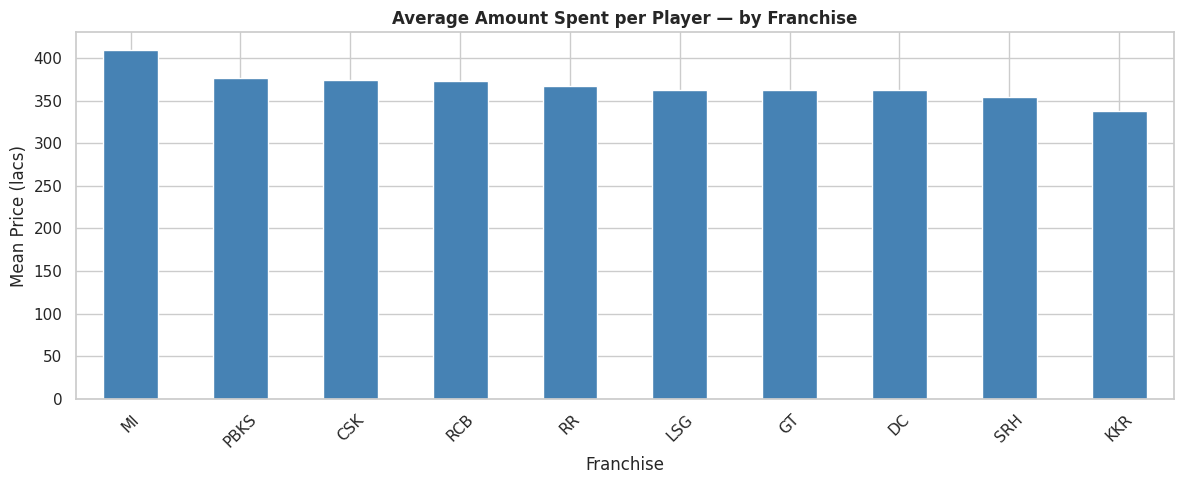

In [25]:
# Bar chart — average spend per player per franchise
plyr_fran_mean = df_filtered.groupby('franchise')['final price (in lacs)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plyr_fran_mean.plot(kind='bar', color='steelblue', grid=True, rot=45)
plt.xlabel('Franchise')
plt.ylabel('Mean Price (lacs)')
plt.title('Average Amount Spent per Player — by Franchise', fontweight='bold')
plt.tight_layout()
plt.show()

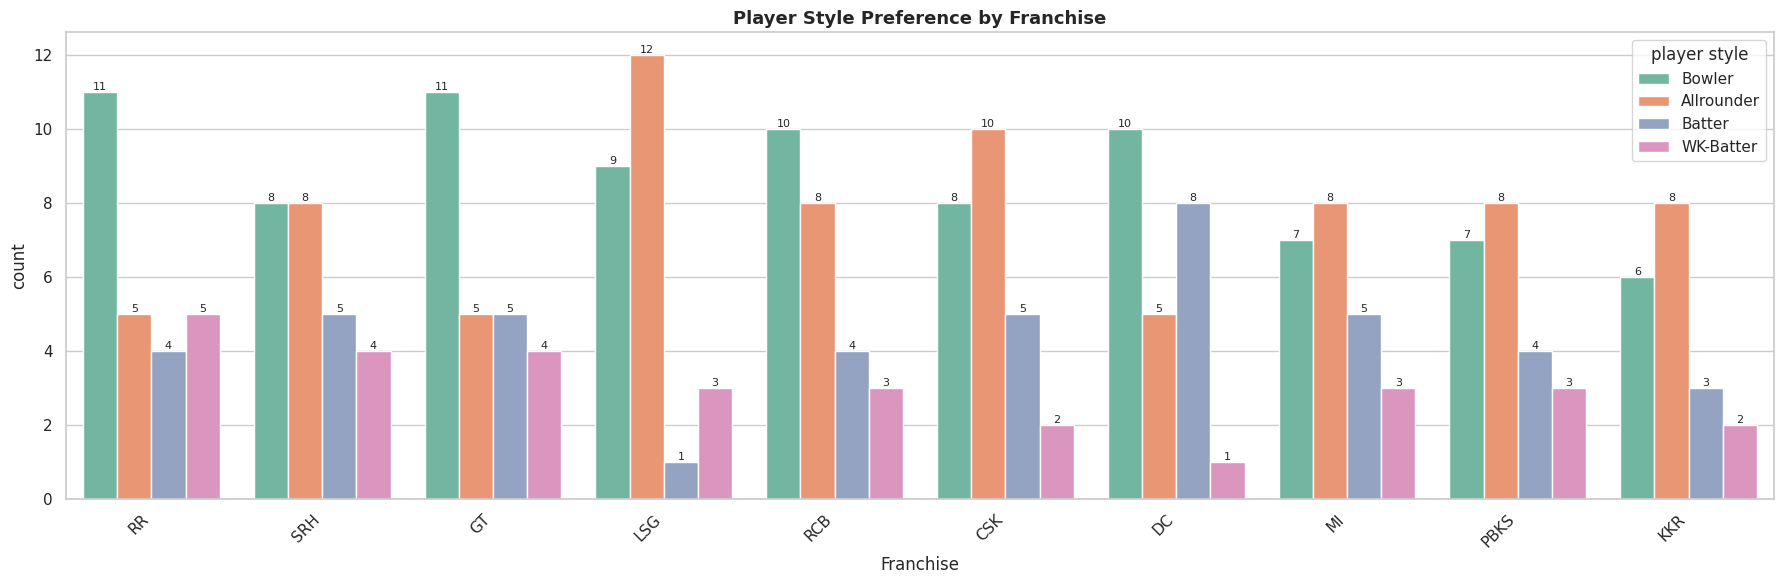

In [26]:
# What player styles did each franchise prefer?
plt.figure(figsize=(18, 6))
ax = sns.countplot(data=df_filtered, x='franchise', hue='player style', palette='Set2',
                   order=df_filtered['franchise'].value_counts().index)
for container in ax.containers:
    ax.bar_label(container, fontsize=8)
plt.title('Player Style Preference by Franchise', fontsize=13, fontweight='bold')
plt.xlabel('Franchise')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 8. Nationality-Level Analysis <a id='8'></a>

Which countries produced the highest-paid players? We focus on the 6 most prominent cricket nations.

In [27]:
# Top earner from each nationality
index = df_filtered.groupby('nationality')['final price (in lacs)'].idxmax()
df_highest = df_filtered.loc[index][['nationality', 'name', 'final price (in lacs)']]
df_highest.sort_values('final price (in lacs)', ascending=False)

,nationality,name,final price (in lacs)
150,England,Sam Curran,1850.0
148,Australia,Cameron Green,1750.0
292,India,KL Rahul,1700.0
136,West Indies,Nicholas Pooran,1600.0
300,Afghanistan,Rashid Khan,1500.0
265,Sri Lanka,Wanindu Hasaranga,1075.0
271,South Africa,Kagiso Rabada,925.0
167,Singapore,Tim David,825.0
276,New Zealand,Trent Boult,800.0
57,Ireland,Joshua Little,440.0


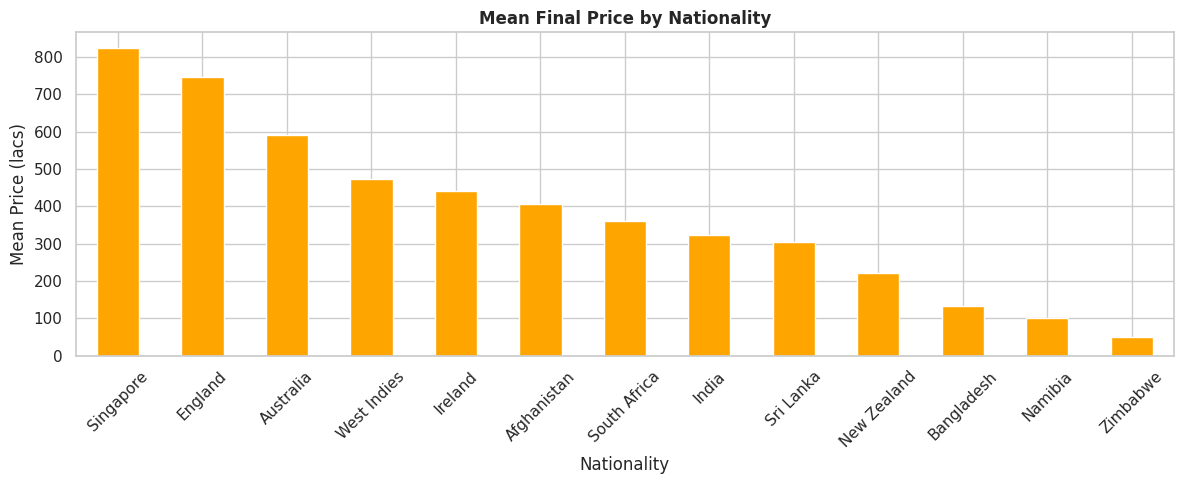

In [28]:
# Mean price per nationality (bar chart)
df_mean_of_nation = df_filtered.groupby('nationality')['final price (in lacs)'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
df_mean_of_nation.plot(kind='bar', color='orange', grid=True, rot=45)
plt.xlabel('Nationality')
plt.ylabel('Mean Price (lacs)')
plt.title('Mean Final Price by Nationality', fontweight='bold')
plt.tight_layout()
plt.show()

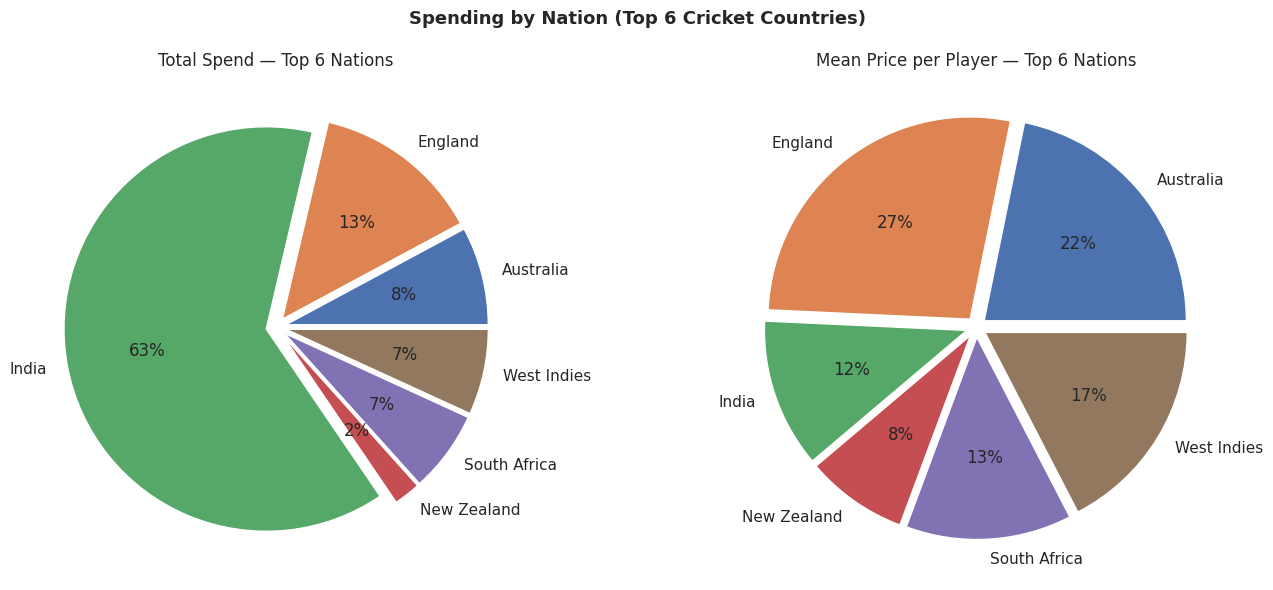

In [29]:
# Focus on top 6 cricket nations — total and average spend (pie charts)
prominent_nations = ['India', 'England', 'West Indies', 'Australia', 'South Africa', 'New Zealand']
df_prom = df_filtered[df_filtered['nationality'].isin(prominent_nations)].copy()

explode = [0.05] * len(prominent_nations)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ser_total = df_prom.groupby('nationality')['final price (in lacs)'].sum()
axes[0].pie(ser_total, labels=ser_total.index, autopct='%1.0f%%', explode=explode)
axes[0].set_title('Total Spend — Top 6 Nations')

ser_mean = df_prom.groupby('nationality')['final price (in lacs)'].mean()
axes[1].pie(ser_mean, labels=ser_mean.index, autopct='%1.0f%%', explode=explode)
axes[1].set_title('Mean Price per Player — Top 6 Nations')

plt.suptitle('Spending by Nation (Top 6 Cricket Countries)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Key Findings <a id='9'></a>

| # | Insight | Detail |
|---|---|---|
| 1 | **Missing values are meaningful** | NaN in `base price` = RETAINED; NaN in `final price` = UNSOLD |
| 2 | **Right-skewed pricing** | Most players sold at lower prices; a few high-value outliers skew the distribution |
| 3 | **Final price > base price spread** | Bidding wars significantly pushed final prices above base values |
| 4 | **All-rounders most expensive** | Mean final price for all-rounders is higher than for bowlers despite similar counts |
| 5 | **India dominates in volume** | Indian players make up the majority by count, though mean prices vary |
| 6 | **Franchise spending is balanced** | Most franchises spent similar amounts per player on average |
| 7 | **Retention favors all-rounders** | All-rounders and WK-batters have the highest retention rates |

---